# Flagging Vendor Invoices for Manual Review

**Objective:** Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value.

- Manual invoice review is time-consuming and does not scale with transaction volume.
- Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes, or compliance risks.
- An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.

In [3]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
conn = sqlite3.connect('/Users/varunxsensei/Desktop/Project/Freight Cost Prediction/data/inventory.db')

In [7]:
tables = pd.read_sql_query("select name from sqlite_master where type = 'table'",conn)

In [8]:
for table in tables['name']:
    print("Table name", table)
    df = pd.read_sql_query(f"select * from {table} limit 5",conn)
    display(df)

Table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [46]:
purchase_agg_df = pd.read_sql_query("""
select p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay

from purchases as p
group by p.PONumber

""",conn)

In [47]:
pd.read_sql_query("""
select 
vi.PONumber,
vi.Quantity as invoice_quantity ,
vi.Dollars as invoice_dollars,
vi.freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) as days_to_pay


from vendor_invoice as vi
""",conn)

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


In [48]:
df = pd.read_sql_query("""
WITH purchase_agg AS (
    SELECT
        p.PONumber,
        COUNT(DISTINCT p.Brand) AS total_brands,
        SUM(p.Quantity) AS total_item_quantity,
        SUM(p.Dollars) AS total_item_dollars,
        AVG(julianday(p.ReceivingDate) - julianday(p.PODate))
            AS avg_receiving_delay
    FROM purchases p
    GROUP BY p.PONumber
)

SELECT
    vi.PONumber,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,

    (julianday(vi.InvoiceDate) - julianday(vi.PODate))
        AS days_po_to_invoice,

    (julianday(vi.PayDate) - julianday(vi.InvoiceDate))
        AS days_to_pay,

    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay

FROM vendor_invoice vi
LEFT JOIN purchase_agg pa
    ON vi.PONumber = pa.PONumber
""", conn)

In [49]:
df.head()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809


In [50]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5543 entries, 0 to 5542
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PONumber             5543 non-null   int64  
 1   invoice_quantity     5543 non-null   int64  
 2   invoice_dollars      5543 non-null   float64
 3   Freight              5543 non-null   float64
 4   days_po_to_invoice   5543 non-null   float64
 5   days_to_pay          5543 non-null   float64
 6   total_brands         5543 non-null   int64  
 7   total_item_quantity  5543 non-null   int64  
 8   total_item_dollars   5543 non-null   float64
 9   avg_receiving_delay  5543 non-null   float64
dtypes: float64(6), int64(4)
memory usage: 433.2 KB


In [55]:
def create_invoice_risk_label(row):
    if abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5:
        return 1
    if row['avg_receiving_delay'] > 10:
        return 1
    
    return 0
        

In [56]:
df['flag_invoice'] = df.apply(create_invoice_risk_label,axis = 1)

<Axes: xlabel='flag_invoice'>

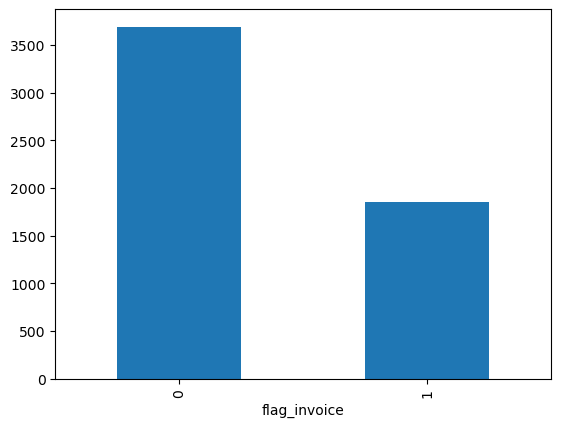

In [57]:
df['flag_invoice'].value_counts().plot(kind = 'bar')

<Axes: >

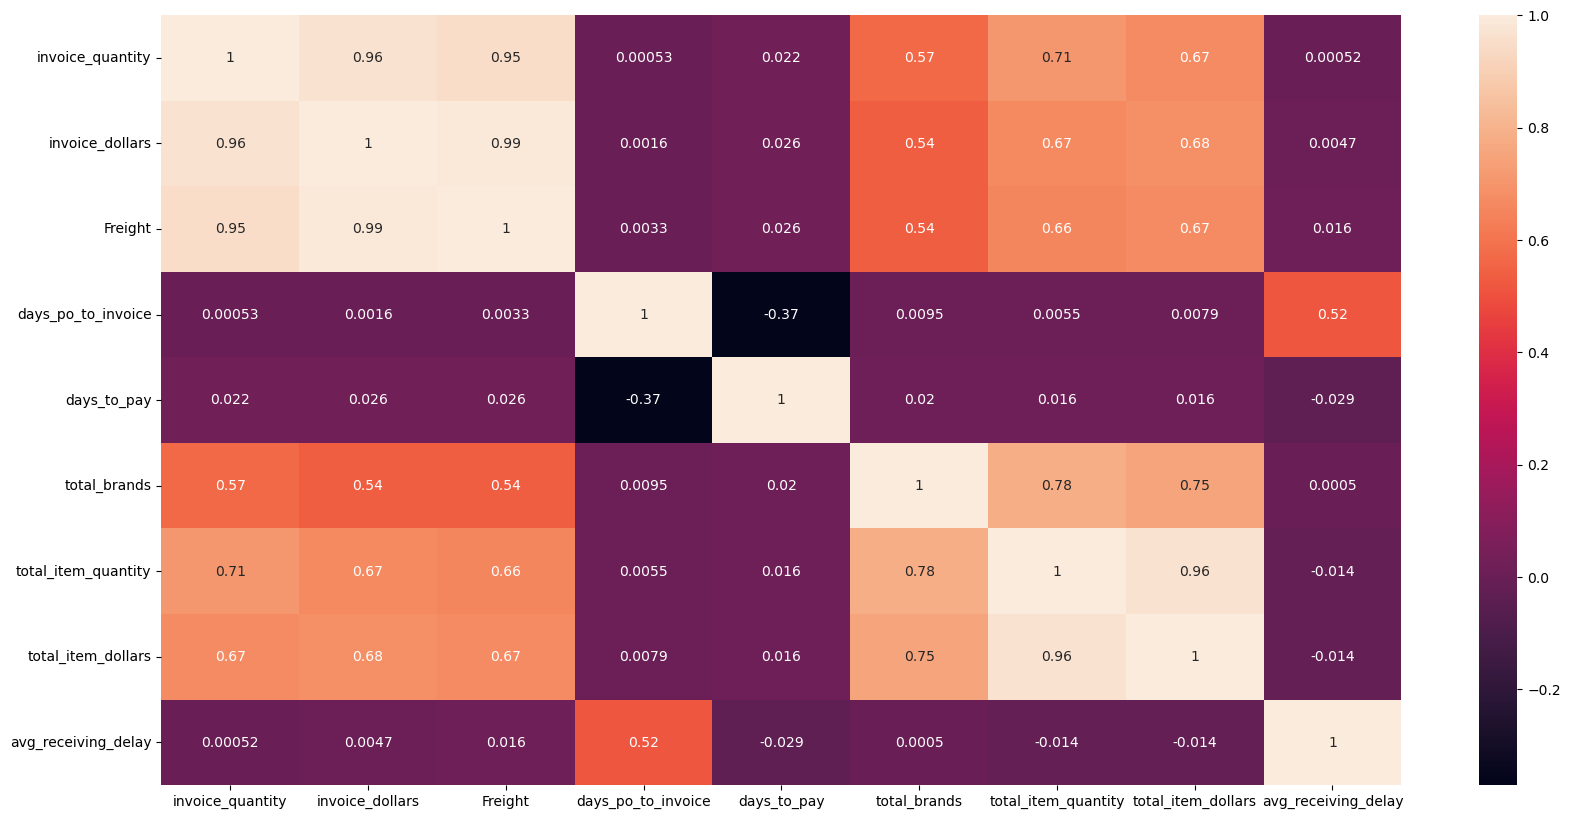

In [58]:
plt.figure(figsize = (20,10))
sns.heatmap(df.iloc[:,1:-1].corr(),annot = True)

In [59]:
flagged = df[df['flag_invoice'] == 1]
normal = df[df['flag_invoice'] == 0]

In [60]:
significant_features = []
non_significant_features = []
results = []

In [61]:
metrics = [
    'invoice_quantity',
    'invoice_dollars',
    'Freight',
    'days_po_to_invoice',
    'days_to_pay',
    'total_brands',
    'total_item_quantity',
    'total_item_dollars',
    'avg_receiving_delay'
]

In [62]:
from scipy.stats import ttest_ind

for metric in metrics:

    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    results.append({
        "metric": metric,
        "flagged_mean": flagged_mean,
        "normal_mean": normal_mean,
        "t_stat": t_stat,
        "p_value": p_value
    })

    if p_value < 0.05:
        significant_features.append(metric)
    else:
        non_significant_features.append(metric)

In [63]:
non_significant_features

['days_to_pay', 'total_brands']

In [64]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [65]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': np.float64(6728.280540540541),
  'normal_mean': np.float64(5723.546709991877),
  't_stat': np.float64(2.303691912622145),
  'p_value': np.float64(0.021304094560069806)},
 {'metric': 'invoice_dollars',
  'flagged_mean': np.float64(65600.60605405405),
  'normal_mean': np.float64(54302.638594638505),
  't_stat': np.float64(2.651798045413994),
  'p_value': np.float64(0.008046854812552176)},
 {'metric': 'Freight',
  'flagged_mean': np.float64(334.0193567567568),
  'normal_mean': np.float64(276.88569726509616),
  't_stat': np.float64(2.6463624783667083),
  'p_value': np.float64(0.008176606234987477)},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': np.float64(17.233513513513515),
  'normal_mean': np.float64(16.019225561873814),
  't_stat': np.float64(13.753046752551812),
  'p_value': np.float64(5.450167647575772e-42)},
 {'metric': 'days_to_pay',
  'flagged_mean': np.float64(35.424864864864865),
  'normal_mean': np.float64(35.4903872190630

In [66]:
X = df[
    [
        'invoice_quantity',
        'invoice_dollars',
        'Freight',
        'total_brands',
        'total_item_quantity',
        'days_po_to_invoice',
        'total_item_dollars'
    ]
]

y = df['flag_invoice']

In [67]:
X.describe()

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars
count,5543.000000,5.543000e+03,5543.000000,5543.000000,5543.000000,5543.000000,5.543000e+03
mean,6058.880931,5.807338e+04,295.954301,41.312466,6058.880931,16.424499,5.807338e+04
std,14453.338164,1.402340e+05,713.585093,76.940674,14453.338164,3.127282,1.402340e+05
min,1.000000,4.140000e+00,0.020000,1.000000,1.000000,9.000000,4.140000e+00
25%,83.000000,9.678100e+02,5.020000,3.000000,83.000000,14.000000,9.678100e+02
50%,423.000000,4.765450e+03,24.730000,7.000000,423.000000,16.000000,4.765450e+03
75%,5100.500000,4.458718e+04,229.660000,46.000000,5100.500000,19.000000,4.458718e+04
max,141660.000000,1.660436e+06,8468.220000,807.000000,141660.000000,23.000000,1.660436e+06


In [68]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [70]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [71]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [74]:
model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled,y_train)
model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled,y_train)
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [78]:
from sklearn.metrics import accuracy_score, classification_report


def evaluate_model(model, X_test, y_test, name):

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"\n{name} Performance:")
    print(f"Accuracy : {accuracy:.2f}")
    print("Classification Report :")

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    return {
        "model_name": name,
        "accuracy": accuracy
    }

In [79]:
evaluate_model(model1,X_test_scaled,y_test,"LogisticRegression")
evaluate_model(model2,X_test_scaled,y_test,"DecisionTreeClassifier")
evaluate_model(model3,X_test_scaled,y_test,"RandomForestClassifier")


LogisticRegression Performance:
Accuracy : 0.66
Classification Report :
              precision    recall  f1-score   support

           0       0.66      0.98      0.79       725
           1       0.56      0.06      0.11       384

    accuracy                           0.66      1109
   macro avg       0.61      0.52      0.45      1109
weighted avg       0.63      0.66      0.55      1109


DecisionTreeClassifier Performance:
Accuracy : 0.81
Classification Report :
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       725
           1       0.74      0.71      0.72       384

    accuracy                           0.81      1109
   macro avg       0.79      0.79      0.79      1109
weighted avg       0.81      0.81      0.81      1109


RandomForestClassifier Performance:
Accuracy : 0.87
Classification Report :
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       725
          

{'model_name': 'RandomForestClassifier', 'accuracy': 0.8746618575293057}

In [80]:
model3.feature_importances_

array([0.15208602, 0.15015318, 0.14429552, 0.0805667 , 0.17730454,
       0.07708204, 0.21851199])

In [82]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model3.feature_importances_
}).sort_values(
    by="importance",
    ascending=False
)

feature_importance

,feature,importance
6,total_item_dollars,0.218512
4,total_item_quantity,0.177305
0,invoice_quantity,0.152086
1,invoice_dollars,0.150153
2,Freight,0.144296
3,total_brands,0.080567
5,days_po_to_invoice,0.077082


In [83]:
X = df[['invoice_quantity','invoice_dollars','Freight','total_item_quantity','total_item_dollars']]
y = df['flag_invoice']

In [84]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [85]:
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [86]:
evaluate_model(model3,X_test_scaled,y_test,"RandomForestClassifier")


RandomForestClassifier Performance:
Accuracy : 0.88
Classification Report :
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       725
           1       0.93      0.72      0.81       384

    accuracy                           0.88      1109
   macro avg       0.90      0.84      0.86      1109
weighted avg       0.89      0.88      0.88      1109



{'model_name': 'RandomForestClassifier', 'accuracy': 0.8836789900811542}

In [88]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"]
}

scorer = make_scorer(f1_score)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

evaluate_model(
    grid_search,
    X_test_scaled,
    y_test,
    "Random Forest Classifier"
)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.4s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   3.6s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=3, n_estimators=200; total time=   2.2s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   1.1s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   2.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time=   3.2s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=300; total time=   3.3s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=2, min_samples_split=3, n_estimators=200; tot

{'model_name': 'Random Forest Classifier', 'accuracy': 0.8881875563570785}

In [89]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 200}